# California Housing Price Prediction — End-to-End ML Pipeline

An end-to-end regression project that predicts median house value for California districts from census data, covering the full workflow: problem framing, EDA, feature engineering, preprocessing pipelines, model selection, hyperparameter tuning, and deployment as a live web app.

**Problem:** A downstream investment-decision system needs an estimate of median district housing price, currently produced manually by domain experts at high cost and with inconsistent accuracy.

**Approach:**
- Stratified train/test split on income category to avoid sampling bias
- EDA on geography, income, and housing-density correlations
- Custom `ColumnTransformer` pipeline (imputation, ratio features, geo similarity via KMeans/RBF, one-hot encoding, scaling)
- Model comparison: Linear Regression → Decision Tree → Random Forest → SVR
- Hyperparameter tuning via `GridSearchCV` / `RandomizedSearchCV`
- Feature importance and bootstrap confidence interval on the held-out test set
- Final model serialized and served through a small web app (see `app.py`)

**Dataset:** California housing census data (`housing.csv`) — 1990 census, ~20,640 districts.

**Stack:** Python, pandas, scikit-learn, matplotlib, Streamlit.


In [9]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
import pandas as pd


# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [11]:
# load up the california data
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 1. Problem Framing & Business Context

Boss wants our model's output (prediction of district's median housing price) will be fed to another Machine Learning system, along with many other signals. This downstream system will determine whether it's worth investing in a given area or not

### Existing (Manual) Solution

The district housing prices are currently estimated manually by experts: a team gathers up-to-date information about a district, and when they cannot get the median housing price, they estimate it using complex rules.This is costly and time-consuming, and their estimates are not great; in cases where they manage to find out the actual median housing price, they often realize that their estimates were off by more than `20%`. This is why the company thinks that it would be useful to train a model to predict a district’s median housing price, given other data about that district. The census data looks like a great dataset to exploit for this purpose, since it includes the median housing prices of thousands of districts, as well as other data.

### System Design

With all this information, you are now ready to start designing your system. First, you need to frame the problem: is it supervised, unsupervised, or Reinforcement Learning? Is it a classification task, a regression task, or something else? Should you use batch learning or online learning techniques? Before you read on, pause and try to answer these questions for yourself.
Have you found the answers? Let’s see: it is clearly a typical `supervised learning` task, since you are given `labeled training` examples (each instance comes with the expected output, i.e., the district’s median housing price). It is also a typical `regression task`, since you are asked to predict a value. More specifically, this is a `multiple regression` problem, since the system will use multiple features to make a prediction (it will use the district’s population, the median income, etc.). It is also a `univariate regression problem`, since we are only trying to predict a single value for each district. If we were trying to predict multiple values per district, it would be a `multivariate regression problem`. Finally, there is no continuous flow of data coming into the system, there is no particular need to adjust to changing data rapidly, and the data is small enough to fit in memory, so plain `batch learning` should do just fine

### Performance Metric

RMSE will tell us how much error the system typically makes in its predictions, with a higher-weight for large errors. Here is the formula

\$\mathrm{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (x_i - y_i)^2}$

In [13]:
# look at data (null values ignored)
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


We clearly see that `total_bedrooms` variable does not have 206040 values whereas everything else has about that many. This clearly tells us that there are null values there which we will have to deal with. It is an important point to note so before we jump in and start doing stuff we will have to clean that column

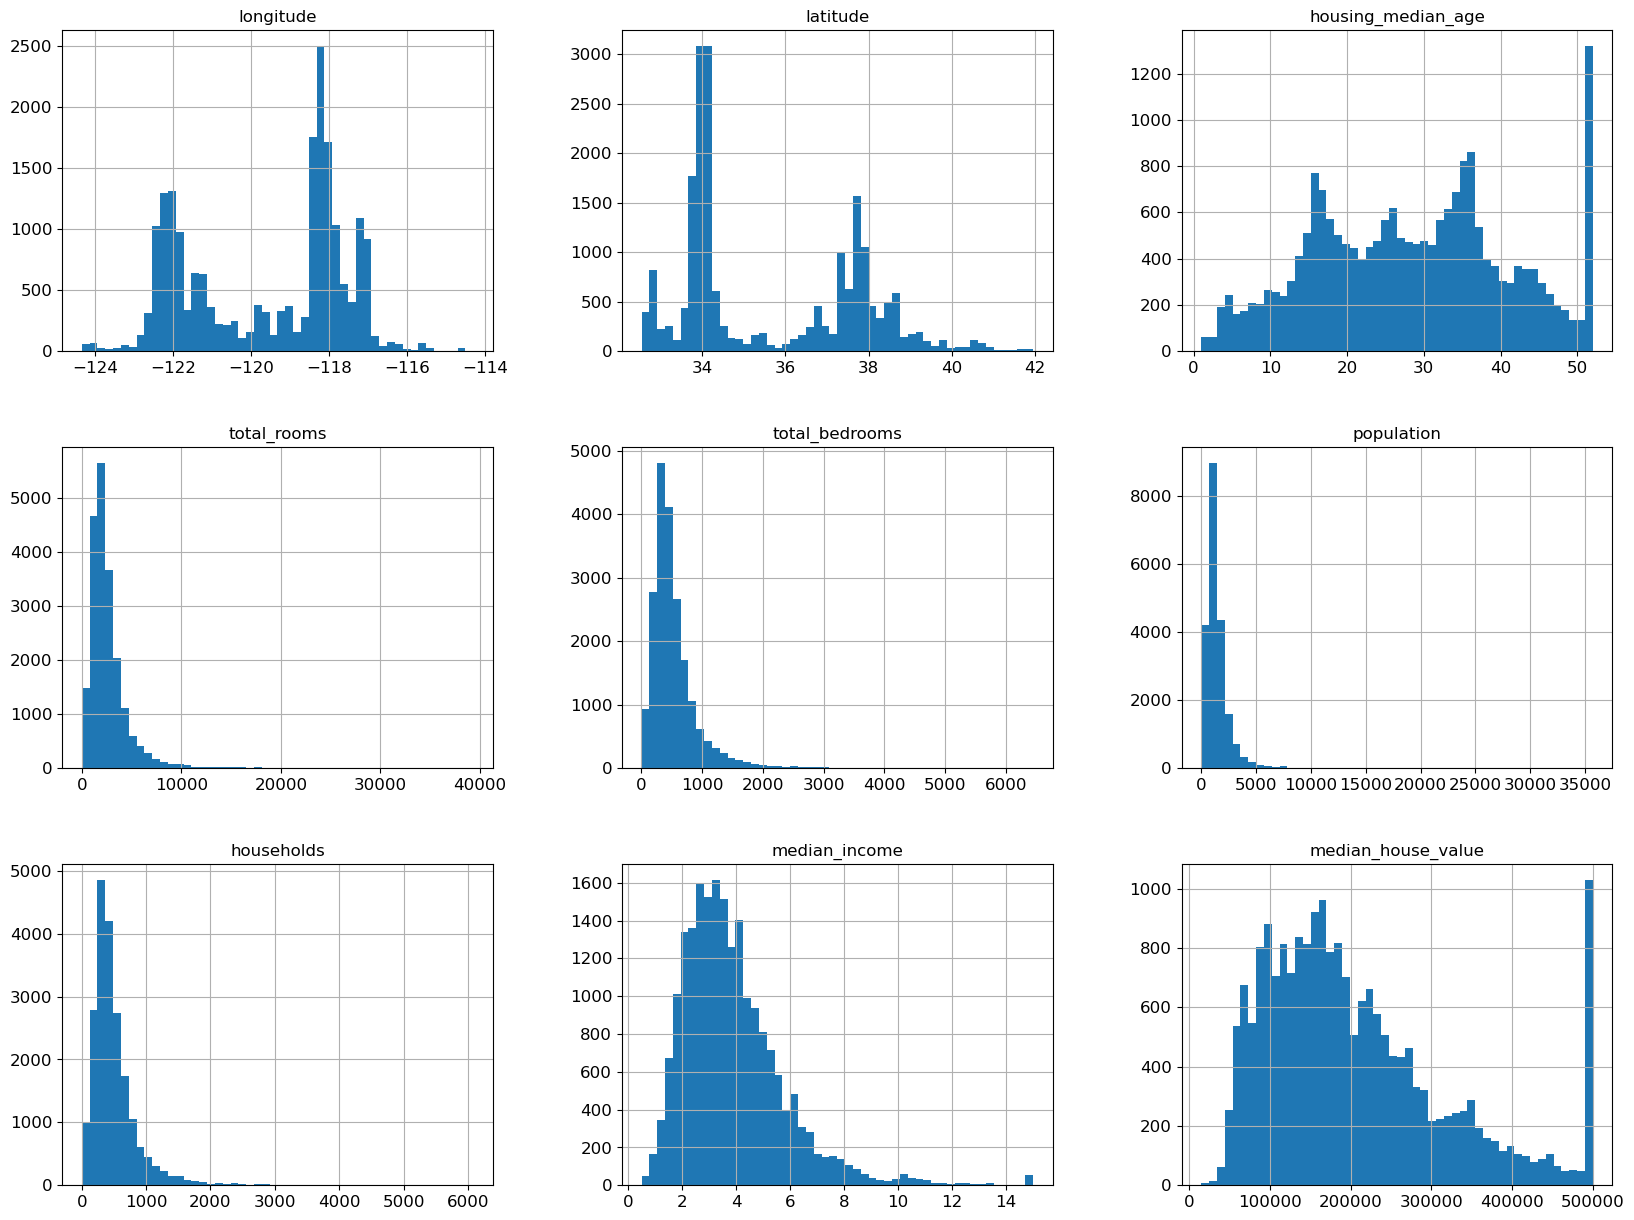

In [5]:
# Let's take a look at all numerical variables visually (distributions
%matplotlib inline 
import matplotlib.pyplot as plt 
df.hist(bins=50, figsize=(20,15))
plt.show()


Main take-away from this is that many distributions seem to be skewed. Mostly right-skewed. Also, we see that some variables seem to be capped at certain values such as the `median_income` variable which is capped at around 15. It represents roughly tens of thousands of dollars our boss tells us. It is important to dig a little deeper into the data you are working with especially when it comes to making conclusions or gaining insights so the correct context is used. 

In [7]:
# Test set to see interesting pattern that will let us select a particular ML model 
# do 20% testing, 80% training preferrably since dataset size is small in ML standards
def split_train_test(data, test_ratio):
    # shuffle data indices (rows basically)
    shuffled_indices = np.random.permutation(len(data))
    # now we will get our test set size
    test_set_size = int(test_ratio * len(data))
    # obtain test set indices and training set indices
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

    
a,b = split_train_test(df, 0.2)

In [13]:
# Let's test our function now
train_set, test_set = split_train_test(df, 0.2)
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10884,-120.85,37.75,26.0,28.0,4.0,9.0,5.0,1.6250,85000.0,INLAND
9801,-117.83,33.82,26.0,3259.0,456.0,1354.0,459.0,5.7817,267600.0,<1H OCEAN
7360,-118.30,33.87,27.0,3144.0,722.0,1510.0,680.0,3.1597,214700.0,<1H OCEAN
3711,-122.08,37.90,29.0,4133.0,770.0,1691.0,744.0,5.1097,288000.0,NEAR BAY
16713,-123.47,39.80,18.0,2130.0,545.0,863.0,346.0,2.3571,79200.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
64,-122.30,37.81,48.0,828.0,182.0,392.0,133.0,2.5938,73500.0,NEAR BAY
2204,-121.96,37.71,6.0,8072.0,1050.0,3386.0,1062.0,7.2494,336500.0,<1H OCEAN
17918,-121.89,36.60,40.0,626.0,164.0,337.0,150.0,2.7917,225000.0,<1H OCEAN
2011,-117.84,33.73,20.0,2572.0,732.0,1534.0,669.0,2.4211,175000.0,<1H OCEAN


In [15]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2613,-121.12,35.58,16.0,4109.0,798.0,1298.0,626.0,3.4799,320800.0,NEAR OCEAN
11510,-120.44,37.29,18.0,1260.0,268.0,576.0,263.0,1.7222,101500.0,INLAND
5016,-117.19,34.03,20.0,856.0,124.0,395.0,145.0,10.8634,381800.0,INLAND
18895,-121.94,37.30,30.0,1758.0,248.0,814.0,256.0,6.6230,332500.0,<1H OCEAN
17964,-122.27,38.53,22.0,678.0,137.0,336.0,103.0,4.4000,142500.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
18567,-119.28,36.33,10.0,1051.0,297.0,927.0,274.0,0.7800,55500.0,INLAND
3713,-119.03,34.23,21.0,3284.0,487.0,1832.0,521.0,5.2773,250800.0,<1H OCEAN
15268,-117.04,32.60,20.0,8052.0,1461.0,5094.0,1430.0,4.2241,139800.0,NEAR OCEAN
9541,-118.24,34.08,52.0,137.0,26.0,65.0,24.0,4.0250,137500.0,<1H OCEAN


This works great, but it generates new random sets each time we run it so the issue is eventually our ML model will have seen the whole dataset which is exactly what we want to avoid!

To have a stable train/test split even after updating the dataset, a common solution is to use each instance’s identifier to decide whether or not it should go in the test set (assuming instances have a unique and immutable identifier). For example, you could compute a hash of each instance’s identifier and put that instance in the test set if the hash is lower than or equal to 20% of the maximum hash value. This ensures that the test set will remain consistent across multiple runs, even if you refresh the dataset. The new test set will contain 20% of the new instances, but it will not contain any instance that was previously in the training set.

In [17]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio)) 
    return data.loc[~in_test_set], data.loc[in_test_set]


df.reset_index()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Unfortunately, the housing dataset does not have an identifier column. The simplest solution is to use the row index as the ID:

In [19]:
housing_with_id = df.reset_index() # adds new index column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, 'index')

train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
6,6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


If you use the row index as a unique identifier, you need to make sure that new data gets appended to the end of the dataset and that no row ever gets deleted. If this is not possible, then you can try to use the most stable features to build a unique identifier. For example, a district’s latitude and longitude are guaranteed to be stable for a few million years, so you could combine them into an ID like so:

In [21]:
housing_with_id["id"] = df['longitude'] * 1000 + df['latitude']
len(housing_with_id['id'].unique())

housing_with_id

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,-121170.51
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57


In [23]:
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")
train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,-121170.51
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57


Scikit-Learn provides a few functions to split datasets into multiple subsets in various ways. The simplest function is train_test_split(), which does pretty much the same thing as the function split_train_test(), with a couple of additional features. First, there is a random_state parameter that allows you to set the random generator seed. Second, you can pass it multiple datasets with an identical number of rows, and it will split them on the same indices (this is very useful, for example, if you have a separate DataFrame for labels):

In [25]:
# does same thing that was done above
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_with_id, test_size=0.2, random_state=42)

So far we have considered purely random sampling methods. This is generally fine if your dataset is large enough (especially relative to the number of attributes), but if it is not, you run the risk of introducing a significant sampling bias. When a survey company decides to call 1,000 people to ask them a few questions, they don’t just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people are representative of the whole population. For example, the US population is 51.3% females and 48.7% males, so a well-conducted survey in the US would try to maintain this ratio in the sample: 513 female and 487 male. This is called stratified sampling: the population is divided into homogeneous subgroups called strata, and the right number of instances are sampled from each stratum to guarantee that the test set is representative of the overall population.

### Back to Analysis

You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset. Since the median income is a continuous numerical attribute, you first need to create an income category attribute. Let’s look at the median income histogram more closely (back in Figure 2-8): most median income values are clustered around 1.5 to 6 (i.e., $15,000–$60,000), but some median incomes go far beyond 6. It is important to have a sufficient number of instances in your dataset for each stratum, or else the estimate of a stratum’s importance may be biased. This means that you should not have too many strata, and each stratum should be large enough. The following code uses the pd.cut() function to create an income category attribute with five categories (labeled from 1 to 5): category 1 ranges from 0 to 1.5 (i.e., less than $15,000), category 2 from 1.5 to 3, and so on:

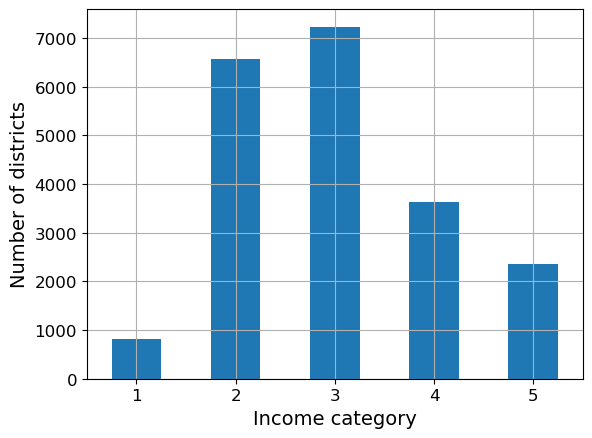

In [27]:
df["income_cat"] = pd.cut(df["median_income"],
                                   bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

cat_counts = df["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

Now you are ready to do stratified sampling based on the income category. For this you can use Scikit-Learn’s StratifiedShuffleSplit class:

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state=42)
strat_splits = []

# generate 10 different stratified splits of the same dataset
for train_index, test_index in splitter.split(df, df['income_cat']):
    strat_train_set_n = df.iloc[train_index]
    strat_test_set_n = df.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [31]:
x = splitter.split(df, df['income_cat']) # each 
x

<generator object BaseShuffleSplit.split at 0x16883f640>

In [33]:
# check first split
strat_train_set, strat_test_set = strat_splits[0]
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,500001.0,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,88800.0,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,148800.0,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,500001.0,<1H OCEAN,3


In [35]:
# alternate way to get this same thing (but this is only for one random split you cannot do multiple with this)
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, stratify=df["income_cat"],random_state=42)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Wont be using this `income_cat`column again so might as well drop it now

Just some nitty gritty stuff and different way to do training and testing sets accounting for bias (preventing it is the goal so we do stratified shuffle)

We spent quite a bit of time on test set generation for a good reason: this is an often
neglected but critical part of a machine learning project. Moreover, many of these
ideas will be useful later when we discuss cross-validation. Now it’s time to move on
to the next stage: exploring the data.

## 2. Exploratory Data Analysis

First, make sure you have put the test set aside and you are only exploring the training set. Also, if the training set is very large, you may want to sample an exploration set, to make manipulations easy and fast. In our case, the set is quite small, so you can just work directly on the full set. Let’s create a copy so that you can play with it without harming the training set:


In [37]:
housing = strat_train_set.copy()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,500001.0,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,88800.0,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,148800.0,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,500001.0,<1H OCEAN,3


Because the dataset includes geographical information (latitude and longitude), it is a good idea to create a scatterplot of all the districts to visualize the data 

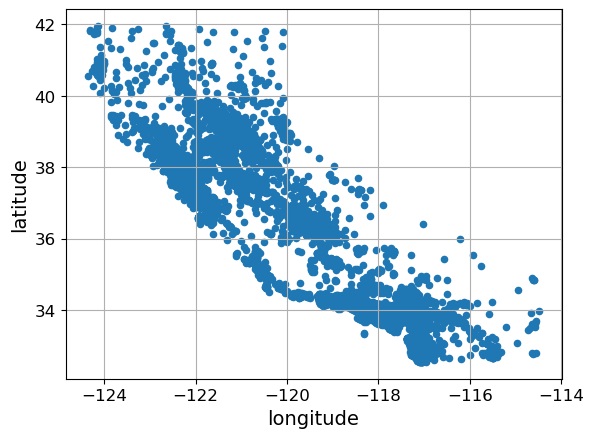

In [39]:
# Note: without grid=True it will not look very thick and as visible as we see it
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True)
plt.show()

If you search up california on the USA map it looks JUST like this like the shape is exactly the same.

This looks like California all right, but other than that it is hard to see any particular
pattern. Setting the alpha option to 0.2 makes it much easier to visualize the places
where there is a high density of data points

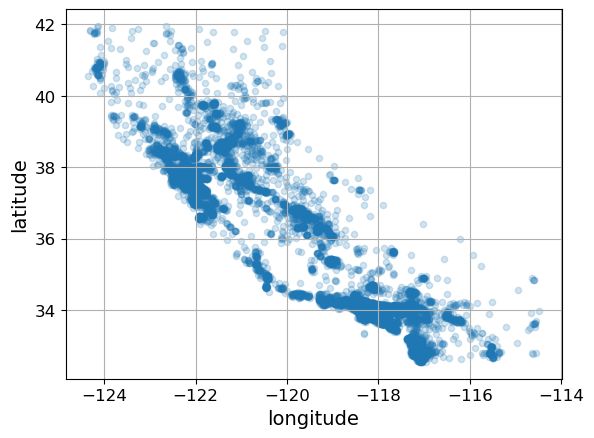

In [41]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True,
            alpha=0.2)
plt.show()

Here we see areas with more density clearly highlighted with the darker blue

Next, lets look at the housing prices . The radius of each circle represents the district’s population (option s), and the color represents the price (option
c). Here you use a predefined color map (option cmap) called jet, which ranges from
blue (low values) to red (high prices)

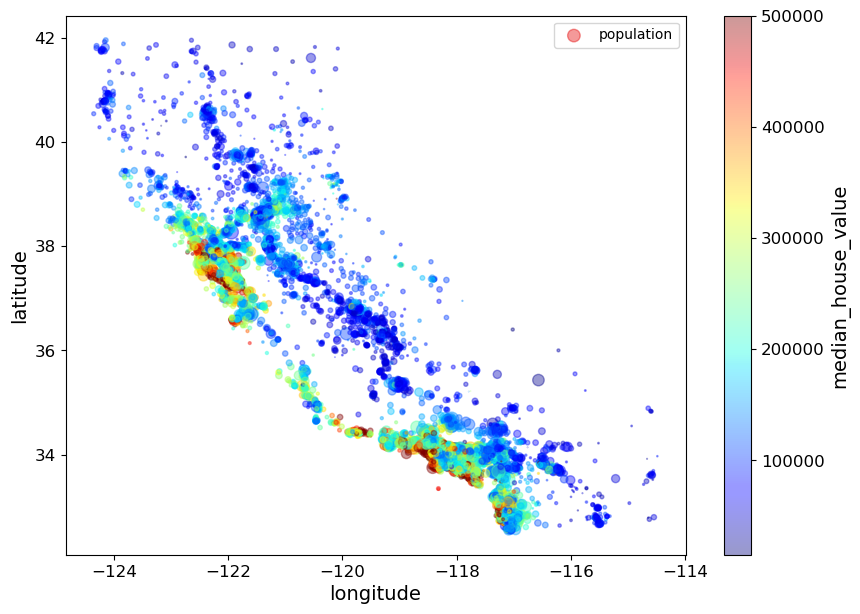

In [43]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=housing["population"]/100, label="population", figsize=(10,7),
        c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    )
plt.legend()

The color map on the side shows us that blue is for low priced areas whereas red is for high priced areas. Large priced areas indicate a larger population from this visualization

This image tells you that the housing prices are very much related to the location (e.g., close to the ocean) and to the population density, as you probably knew already. A clustering algorithm should be useful for detecting the main cluster and for adding new features that measure the proximity to the cluster centers. The ocean proximity attribute may be useful as well, although in Northern California the housing prices in coastal districts are not too high, so it is not a simple rule.

### Correlation Analysis

In [45]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


Looking at how each attribute correlates with the `median_house_value`

In [47]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

`latitude` measures location south or north of equator. By that logic we can interpret the -0.139584 coefficient which shows a slightly negative correlation between `median_house_value` and `latitude`. It can be interpreted as follows; as you go north (positive latitude coefficient would mean south), prices begin to decrease. 

Another way to check for correlation between attributes is to use the Pandas
scatter_matrix() function, which plots every numerical attribute against every
other numerical attribute. Since there are now 9 numerical attributes, you would
get 9^2
= 81 plots, which would not fit on a page—so you decide to focus on a
few promising attributes that seem most correlated with the median housing value

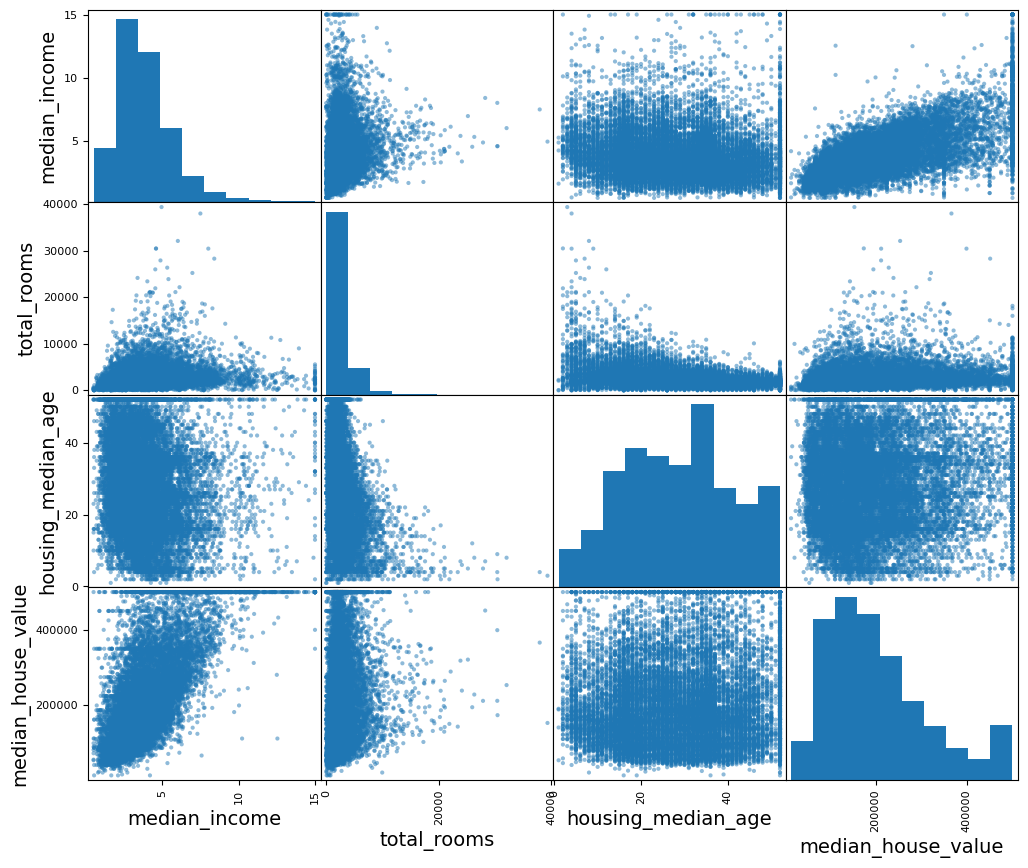

In [49]:
from pandas.plotting import scatter_matrix

# since 11 variables, it would plot 11^2 = 121 plots so let's just focus on most correlated ones with median_housing_value
attributes = ['median_income', 'total_rooms', 'housing_median_age', 'median_house_value']
scatter_matrix(housing[attributes], figsize=(12,10))
plt.show()

It seems that the `median_income` variable seems to have a strong correlation coefficient so let's zoom in on that plot (these are all histograms btw)

<Axes: xlabel='median_income', ylabel='median_house_value'>

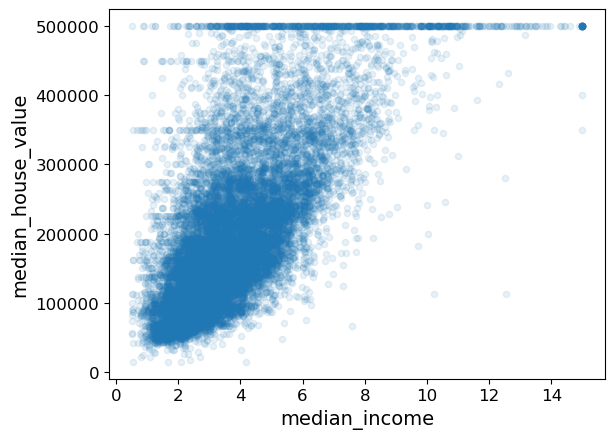

In [51]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1)

- Income seems capped as we learned at the beginning of our project
- These may be outliers that we may have to deal with to prevent our model from being quirky

### Engineered Feature Candidates



Hopefully the previous sections gave you an idea of a few ways you can explore the data and gain insights. You identified a few data quirks that you may want to clean up before feeding the data to a Machine Learning algorithm, and you found interesting correlations between attributes, in particular with the target attribute. You also noticed that some attributes have a tail-heavy distribution, so you may want to trans‐ form them (e.g., by computing their logarithm). Of course, your mileage will vary considerably with each project, but the general ideas are similar.

One last thing you may want to do before preparing the data for Machine Learning algorithms is to try out various attribute combinations. For example, the total num‐ ber of rooms in a district is not very useful if you don’t know how many households there are. What you really want is the number of rooms per household. Similarly, the total number of bedrooms by itself is not very useful: you probably want to compare it to the number of rooms. And the population per household also seems like an interesting attribute combination to look at. Let’s create these new attributes:

In [53]:
# preparing data for ML algorithms
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [55]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_house,bedrooms_ratio,people_per_house
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3,3.725256,0.277371,1.631399


In [ ]:
# housing = housing.drop(columns=['bedrooms_per_room'])

In [57]:
# look at new correlation matrix now
corr_matrix = housing.select_dtypes(include=['int', 'float']).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

The new variables we added, seem to have some correlation with the `median_house_value` variable. That's great and what we are looking for! Apparently, it seems that houses with a lower bedroom/room ratio tend to be more expensive. 

Hey, not bad! The new bedrooms_per_room attribute is much more correlated with the median house value than the total number of rooms or bedrooms. Apparently houses with a lower bedroom/room ratio tend to be more expensive. The number of rooms per household is also more informative than the total number of rooms in a district—obviously the larger the houses, the more expensive they are.

This round of exploration does not have to be absolutely thorough; the point is to start off on the right foot and quickly gain insights that will help you get a first rea‐ sonably good prototype. But this is an iterative process: once you get a prototype up and running, you can analyze its output to gain more insights and come back to this exploration step.


## 3. Data Preparation

It’s time to prepare the data for your Machine Learning algorithms. Instead of doing this manually, you should write functions for this purpose, for several good reasons:

- This will allow you to reproduce these transformations easily on any dataset (e.g., the next time you get a fresh dataset).
- You will gradually build a library of transformation functions that you can reuse in future projects.
- You can use these functions in your live system to transform the new data before feeding it to your algorithms.

Very quickly let us revert back to a clean training set since we have worked on the current one too much for data exploration. Let's utilize our `set_train_set`again.

In [59]:
housing = strat_train_set.drop('median_house_value',axis=1) # predictors (axis=1 cuz we are not losing any rows just columns)
housing_labels = strat_train_set['median_house_value'].copy()



### Handling Missing Values

Most Machine Learning algorithms cannot work with missing features, so let’s create a few functions to take care of them. We saw earlier that the total_bedrooms attribute has some missing values, so let’s fix this. You have three options:
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the values to some value (zero, the mean, the median, etc.).

In [61]:
housing.dropna(subset=["total_bedrooms"]) # option 1
housing.drop("total_bedrooms", axis=1) # option 2
median = housing["total_bedrooms"].median() # option 3

Scikit-Learn provides a handy class to take care of missing values: SimpleImputer. Here is how to use it. First, you need to create a SimpleImputer instance, specifying that you want to replace each attribute’s missing values with the median of that attribute:

In [63]:
from sklearn.impute import SimpleImputer

# instantiate an instance
imputer = SimpleImputer(strategy='median')

# Since the median can only be computed on numerical attributes, you need to create a copy of the data without the text 
# attribute ocean_proximity:

housing_num = housing.drop('ocean_proximity',axis=1)

# fit the imputer instance to the training data using the fit() method
imputer.fit(housing_num)

# not sure if future data will have missing values so the imputer has simply computed the median of each attribute and stored the result in
# an instance variable. Of course only the `median_house_value` had missing values safer to apply imputer to all so in the future issues
# don't rise up with more missing values

# instance
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385,    3.    ])

In [65]:
# same thing as imputer.statistics_
housing_num.drop(columns='income_cat').median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [67]:
# now we can use this trained imputer to transform missing values using our training set
# compute design matrix
X = imputer.transform(housing_num)


The result is a plain NumPy array containing the transformed features. If you want to
put it back into a pandas DataFrame, it’s simple:

In [69]:
housing_num_clean = pd.DataFrame(X, columns=housing_num.columns,
                               index=housing_num.index)
housing_num_clean


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,2.0
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,5.0
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,2.0
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,2.0
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,3.0
...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,4.0
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,2.0
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,3.0
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,3.0


Very quickly let us now deal with the non-numerical attribute which we haven't looked at much; `ocean_proximity`

In [71]:
# machine learning requires us to work mostly with numbers so let us encode these categories
housing_cat = housing[['ocean_proximity']]
housing_cat.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [73]:
housing_cat['ocean_proximity'].unique()
# not many many values, let's encode it (just 4 diff options)
from sklearn.preprocessing import OrdinalEncoder
original_encoder = OrdinalEncoder()
housing_cat_encoded = original_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10] # clearly we see only 4 possible values here just numbers replaced instead of the categories we had above before

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [75]:
housing_cat['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [77]:
original_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

This method is only good however if we were working with stuff like 'bad', 'good', 'excellent' but in our case for the `ocean_proximity` column it'll cause similarity issues (distance between 0 and 1 = 1 distance between 0 and 4 = 4 so some categories will be assumed to be closer to others and etc. but they are geographically related...). BETTER solution is to hot-encode it so you only have 0s and 1s. 

One attribute equal to 1 when the category is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the category is “INLAND” (and 0 otherwise), and so on. Called dummy attributes. This is good to do because these are nominal categorical variables we are working with which have no natural order for example, in the 'good', 'bad', 'excellent' thing labelling 0 as bad, 1 as good and 2 as excellent wouldn't be such a bad idea at all. In our case however no one category is numerically related to one another and thus not similar whatsoever speaking in data science terms. They have no hierarchy or rankings.

In [79]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [81]:
housing_cat_1hot.toarray() 

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Notice each row has a 1. In the first row for example the first entry corresponds to `ocean_proximity` = `NEAR BAY` which is assigned 1 because the hot encoder is assigning it the 'important' value to show that this category is `NEAR BAY`. We can check the ordering using `cat_encoder.categories_`. Below we see that `NEAR BAY` is assigned as the third in this natural order. So for `1H OCEAN` for example we would have a 1 in the first column, for `INLAND`, in the 2nd, and etc. 

In [83]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [85]:
housing_cat

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
...,...
14207,<1H OCEAN
13105,INLAND
19301,NEAR OCEAN
19121,<1H OCEAN


In [87]:
# Using this we can get the sparse array directly
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

If a categorical attribute has a large number of possible categories (e.g., country code, profession, species), then one-hot encoding will result in a large number of input features. This may slow down training and degrade performance. If this happens, you may want to replace the categorical input with useful numerical features related to the categories: for example, you could replace the ocean_proximity feature with the distance to the ocean (similarly, a country code could be replaced with the country’s population and GDP per capita). Alternatively, you could replace each category with a learnable, low-dimensional vector called an embedding. Each category’s representation would be learned during training. This is an example of representation learning.

### Dummy Variables

Pandas has a function called get_dummies(), which also converts each categorical
feature into a one-hot representation, with one binary feature per category:

In [89]:
df_test = pd.DataFrame({'ocean_proximity': ['INLAND', 'NEAR BAY']})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


It looks nice and simple, so why not use it instead of OneHotEncoder? Well, the
advantage of OneHotEncoder is that it remembers which categories it was trained
on. This is very important because once your model is in production, it should be
fed exactly the same features as during training: no more, no less. Look what our
trained cat_encoder outputs when we make it transform the same df_test (using
transform(), not fit_transform()):

In [91]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

See the difference? get_dummies() saw only two categories, so it output two columns,
whereas OneHotEncoder output one column per learned category, in the right order.
Moreover, if you feed get_dummies() a DataFrame containing an unknown category
(e.g., "<2H OCEAN"), it will happily generate a column for it:

In [93]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In an actual pipeline that will be deployed using `pd.get_dummies()` is a bad idea since it will not catch the exception when your training and testing data don't match. Utilizing the more powerful `HotOneEncoder()` object is far more useful here.

In [95]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

When you fit any Scikit-Learn estimator using a DataFrame, the estimator stores the
column names in the feature_names_in_ attribute. Scikit-Learn then ensures that
any DataFrame fed to this estimator after that (e.g., to transform() or predict())
has the same column names. Transformers also provide a get_feature_names_out()
method that you can use to build a DataFrame around the transformer’s output:

In [97]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [99]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [101]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                        columns=cat_encoder.get_feature_names_out())

df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


In [103]:
min(housing.total_rooms)

2.0

### Feature Scaling

Currently, we have rooms ranging from like 2 to 39k+ with median incomes ranging from 0-15 to work. Pretty ridicolous scale so we have to adjust it for our ML model to not be biased towards the insane amount of rooms

There are two ways to do this. One is **standardization** and the other is **normalization**. 

**Normalization** is quite simple. You change the range of every attribute from 0 to 1. Simply do **(x - min) / (max - min)**

In [105]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1)) # could do (0,1) instead too
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num_min_max_scaled
# clearly all values are between -1 and 1 here

array([[-0.60851927,  0.11702128,  1.        , ..., -0.61433638,
        -0.7794789 , -0.5       ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.86708979,
        -0.22929339,  1.        ],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.92458466,
        -0.73336919, -0.5       ],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.71663244,
        -0.50873781,  0.        ],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.68751167,
        -0.49716556,  0.        ],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.92122457,
        -0.61608805,  0.        ]])

**Standardization** I'm more familiar with, it's just computing z-score so do 
                                                    z = (x bar - mean) / std dev.
**Standardization** is also pretty nice because you don't have to worry about any range (remember popping integrals in stats 2 the -inf to +inf ones) and it is also much less affected by outliers.                                       

In [107]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_standardized = std_scaler.fit_transform(housing_num)

housing_num_standardized

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  1.39481249,
        -0.93649149, -0.95468705],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.37348471,
         1.17194198,  1.89007821],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.77572662,
        -0.75978881, -0.95468705],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.67913534,
         0.1010487 , -0.00643196],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.88286825,
         0.14539615, -0.00643196],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.75221898,
        -0.31034135, -0.00643196]])

Note: If you want to scale a sparse matrix without converting it to a dense
matrix first, you can use a StandardScaler with its with_mean
hyperparameter set to False: it will only divide the data by the
standard deviation, without subtracting the mean (as this would
break sparsity).

### Dealing with heavy tails

Transform data using log or something because min-max and standardization scaling with squash values into a small range and make it not be representative of the true dataset.  Essentially we shrink the tail and adjust it to look like a normal distribution

array([[<Axes: title={'center': 'population'}>]], dtype=object)

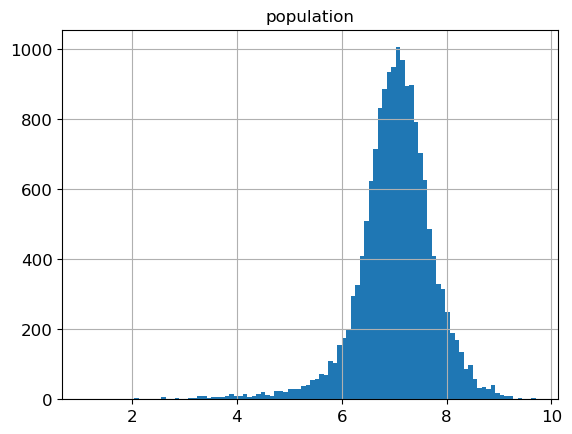

In [109]:
# try log or square root
housing_num_copy = housing_num.copy()
housing_num_copy['population'] = np.log(housing_num_copy['population'])

housing_num_copy.hist('population', bins=100)

In [1]:
housing_num.hist('population', bins=100)

NameError: name 'housing_num' is not defined

array([[<Axes: title={'center': 'population'}>]], dtype=object)

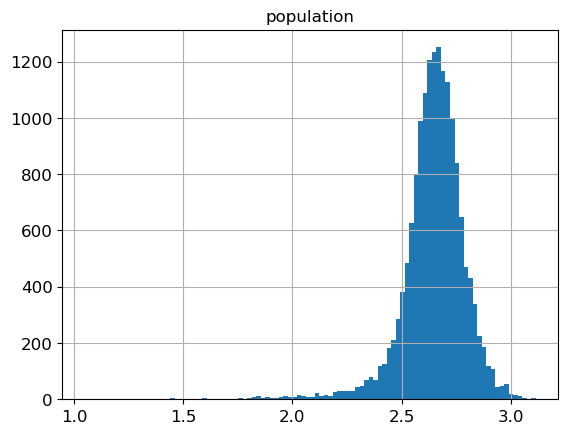

In [113]:
# trying with sqrt also cuz why not
housing_num_copy['population'] = np.sqrt(housing_num_copy['population'])

housing_num_copy.hist('population', bins=100)

In [115]:
# now let's min-max scale on sqrt 
min_max_scaled = MinMaxScaler(feature_range=(0,1))
housing_num_copy_min_max_scaled = min_max_scaled.fit_transform(housing_num_copy)

housing_num_copy_min_max_scaled

# works, not all values are 0.0334 or something 

array([[0.19574037, 0.55851064, 1.        , ..., 0.19283181, 0.11026055,
        0.25      ],
       [0.60547667, 0.16914894, 0.76470588, ..., 0.06645511, 0.38535331,
        1.        ],
       [0.24036511, 0.61808511, 0.62745098, ..., 0.03770767, 0.1333154 ,
        0.25      ],
       ...,
       [0.73935091, 0.00425532, 0.23529412, ..., 0.14168378, 0.24563109,
        0.5       ],
       [0.60344828, 0.1606383 , 0.70588235, ..., 0.15624417, 0.25141722,
        0.5       ],
       [0.19675456, 0.54361702, 0.84313725, ..., 0.03938772, 0.19195597,
        0.5       ]])

### This is naive regardless because we are not taking care of our geographical features independently. 

Alternative approach is to use something called **bucketizing** the feature which means to chop down distirbution into roughly equal sized buckets and then replacing each feature value wiht index of bucket it belongs to similar to the `income_cat` feature

For example we replace each value with its percentile and then **bucketizing** with equal-sized buckets results in a feature with almost uniform distribution so no need for further scaling or just divide by number of buckets to force the 0-1 range

Another approach to transforming multimodal distributions (one way is bucketizing features as categorical and hot encoding so regression model easily learns diff rules for diff ranges of this feature value) is to use **rbf_kernel** function in Python. You add a feature for each of the main modes that computes similiarity between the housing median and age and a particular mode

In [117]:
from sklearn.metrics.pairwise import rbf_kernel

age_siml_35 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma=0.1)



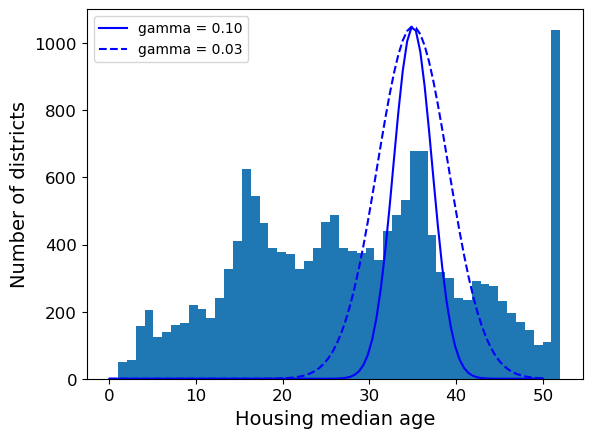

In [119]:
# 1. Just plot your normal histogram first
plt.hist(housing['housing_median_age'], bins=50)
plt.xlabel("Housing median age")
plt.ylabel("Number of districts")

# 2. Create a smooth line from age 0 to 50
age_axis = np.linspace(0, 50, 100).reshape(-1, 1)

# 3. Calculate kernels and multiply by 1050 so they match the histogram height from book 
line_010 = rbf_kernel(age_axis, [[35]], gamma=0.10) * 1050
line_003 = rbf_kernel(age_axis, [[35]], gamma=0.03) * 1050

# 4. Draw the lines directly on top
plt.plot(age_axis, line_010, color='blue', linestyle='-', label='gamma = 0.10')
plt.plot(age_axis, line_003, color='blue', linestyle='--', label='gamma = 0.03')

plt.legend(loc="upper left")
plt.show()


If this particular age group is well correlated with lower prices, there's a good chance that this new feature will help

### Now we look at transforming the target variables (just did input) and `inverse_transform` method

In [121]:
housing_labels

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64

In [123]:
housing['median_income']

13096    2.0987
14973    6.0876
3785     2.4330
14689    2.2618
20507    3.5292
          ...  
14207    4.7105
13105    2.5733
19301    4.0616
19121    4.1455
19888    3.2833
Name: median_income, Length: 16512, dtype: float64

In [125]:
from sklearn.linear_model import LinearRegression

target_scalar = StandardScaler()
scaled_labels = target_scalar.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']], scaled_labels)

new_data = housing[['median_income']].iloc[:5] # pretend new data

scaled_predictions = model.predict(new_data)
predictions = target_scalar.inverse_transform(scaled_predictions)

predictions

# really unnecessary but shows thinking and should be done before efficient method to understand whats going on behind the scenes

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

Simpler method is constructing a `TransformedTargetRegressor` obect which avoids potential scaling mismatches . Automatically uses transformer to scale labels and train regression model on the resulting scaled labels as we have done before. 

In [127]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=LinearRegression(),
                                  transformer=StandardScaler())

model.fit(housing[['median_income']], housing_labels)
predictions = model.predict(new_data)

predictions

# very efficient and useful

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

### Custom Transformers

To write your own tasks, cleanup operations or combining specific attributes an all in one. Look below how easy we can do a log transformation

In [129]:
new_data = housing.iloc[:5]
new_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN,3


In [139]:
from sklearn.preprocessing import FunctionTransformer

# inverse_func is optional: useful if you will be using this transformer in a TransformedTargetRegressor
log_transformer = FunctionTransformer(func=np.log, inverse_func = np.exp) 
log_pop = log_transformer.transform(housing['population'])

# create new model where we are doing median_income = log(median_income_price) = B_0 + B_1 * log(population)
model_log = TransformedTargetRegressor(regressor=LinearRegression(),
                          transformer=log_transformer,
                                      )

# transform our predicted dataset now
log_pop_new = log_transformer.transform(housing['population'])
log_pop_new

13096    7.362645
14973    6.501290
3785     6.331502
14689    7.520235
20507    7.555905
           ...   
14207    6.843750
13105    7.257708
19301    7.942362
19121    7.452982
19888    6.525030
Name: population, Length: 16512, dtype: float64

In [141]:
# suppose we wanted our transformer to compute the Gaussian RBF similarity measure
# notice using kwargs cuz they are hyperparameters as additional arguments
rbf_transformer = FunctionTransformer(func=rbf_kernel,
                                     kw_args=dict(Y=[[35.]], gamma=0.1))

age_simil_35 = rbf_transformer.transform(housing[['housing_median_age']])

age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

Quic note: **RBF kernel** has no inverse function since there are always 2 values at a given distance from a fixed point (except at distance 0). Also it doesn't treat features separately. If we pass in an array with just two features like below it will measure Euclidean distance (2D distance) to measure similarity. Example below to measure geographical similarity between each district and San Fransisco.

In [143]:
sf_coords = 37.7749, -122.41

sf_transformer = FunctionTransformer(func=rbf_kernel,
                                    kw_args=dict(Y=[sf_coords], gamma=0.1))

sf_simil = sf_transformer.transform(housing[['latitude', 'longitude']])

sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]])

`FunctionTransformer` is pretty good but if you want to train your transform, learn parameters in the `fit()` method and use them later in the `transform()` method you gotta write your own custom class and define it. 

Here's a customer transformer that acts a lot like the `StandardScalar`

In [145]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalarClone(BaseEstimator, TransformerMixin):

    def __init__(self, with_mean=True): # no args or kwargs 
        # instantiate constructor 
        self.with_mean = with_mean

    def fit(self, X, y=None): # need y despite not using it
        X = check_array(X) # checks if X is an array with a finite number of floats
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1] # every estimator stores this in fit() and it's because we store our features
        # in the columns section, if we did X.shape[0] that would be the rows which # of obs.
        return self # always return self

    def transform(self, X): # looks for learned attributes 
        check_is_fitted(self)
        X = check_array(X) # check this again kinda stupid but its needed i guess
        assert self.n_features_in_ == X.shape[1] # check this again too even though we just assigned above
        if self.with_mean: # so if there is a mean value which there should
            X = X - self.mean_
        return X / self.scale_


# quick test this thing works...(same code as earlier just diff variables and new function that should do same thing)
std_scaler_clone = StandardScalarClone()
housing_num_standardized2 = std_scaler_clone.fit_transform(X)

housing_num_standardized2

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  1.39481249,
        -0.93649149, -0.95468705],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.37348471,
         1.17194198,  1.89007821],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.77572662,
        -0.75978881, -0.95468705],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.67913534,
         0.1010487 , -0.00643196],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.88286825,
         0.14539615, -0.00643196],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.75221898,
        -0.31034135, -0.00643196]])

In [147]:
housing_num_standardized.all() == housing_num_standardized2.all() # yup amazing

True

In [149]:

# Feature observations (3 samples, 2 features)
X_features = np.array([
    [1.5, 2.0],
    [2.0, 2.5],
    [3.0, 3.5]
])

# Add a column of ones for the intercept (bias term)
intercept = np.ones((X_features.shape[0], 1))
design_matrix = np.hstack((intercept, X_features))

print(design_matrix)

design_matrix.shape[1]

[[1.  1.5 2. ]
 [1.  2.  2.5]
 [1.  3.  3.5]]


3

Another example can be seen below. Here is a custom written transformer that uses a `KMeans` clusterer in the `fit()` method to identify the main clusters in the training data, and then uses `rbf_kernel` in the `transform()` method to measure how similar each sample is to each cluster center

In [151]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):

    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self!

    def transform(self, X):
        return rbf_kernel(X,self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
        

In [153]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1,random_state=42)
similarities = cluster_simil.fit_transform(housing[['latitude', 'longitude']])

In [155]:
similarities[:3].round(2)

array([[0.46, 0.  , 0.08, 0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  ],
       [0.  , 0.96, 0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.11, 0.35],
       [0.34, 0.  , 0.45, 0.  , 0.  , 0.  , 0.01, 0.73, 0.  , 0.  ]])

In [159]:
# x and y are length 16512
len(similarities.max(axis=1)) # to compress our 165120 values let's just pick max for simplicty
# do axis = 1 cuz that collapses the columns and you end up with JUST 16512 values (10 times less)


16512

In [161]:
similarities.shape

(16512, 10)

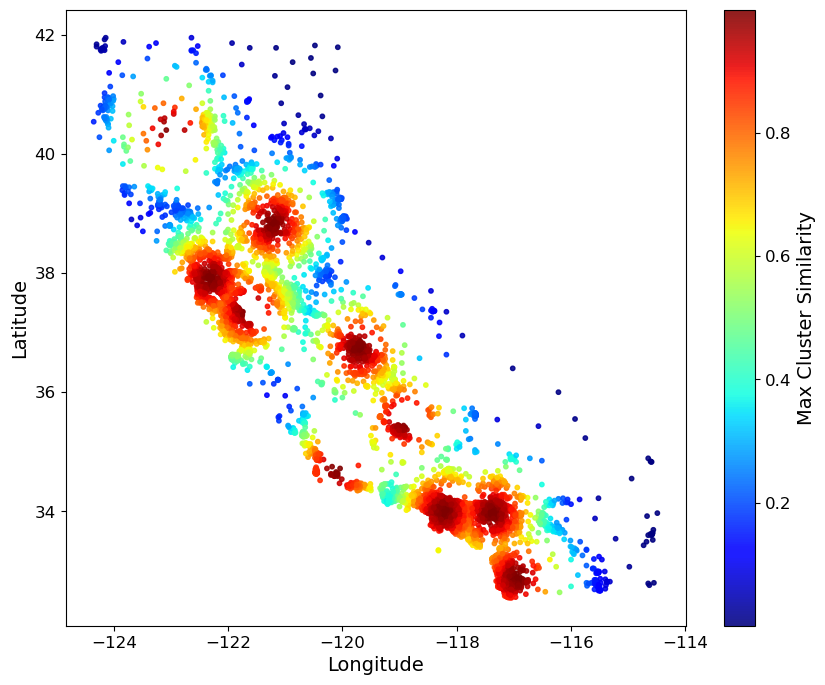

In [163]:
fig, ax = plt.subplots(figsize=(10,8))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.scatter(housing_num['longitude'], 
            housing_num['latitude'],
            c=similarities.max(axis=1),
            cmap='jet',
            alpha=0.88,
            s=10
           )
plt.colorbar(label='Max Cluster Similarity')

plt.show()


Most clusters are located in highly populated areas clearly

### Preprocessing Pipeline

Here we ustilize the `Pipeline`method to deal with numerical attributes quickly. Really useful for hyperparameter tuning later

In [165]:
sklearn.set_config(display='diagram')

In [167]:
from sklearn.pipeline import Pipeline

# here we name and create TWO transformers: impute and standardize
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ('standardize', StandardScaler())
    
])


# shorter method if you don't want to customize and name your transformers
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [169]:
# call fit_transform and see what happened
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

# standardized data (z-score) and replaced all missing values with median 

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94, -0.95],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17,  1.89]])

In [171]:
df_housing_num_prepared = pd.DataFrame(housing_num_prepared,
                                      columns=num_pipeline.get_feature_names_out(),
                                      index=housing_num.index)

df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.954687
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.890078
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,-0.954687
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,-0.954687
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,-0.006432
...,...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.140152,-0.445315,0.060101,0.444041,0.941823
13105,0.131525,0.319822,-0.443146,0.139847,0.128298,-0.005950,0.083608,-0.685630,-0.954687
19301,1.256209,-1.428701,-1.237721,0.586026,0.562134,1.268299,0.679135,0.101049,-0.006432
19121,0.586397,-0.739605,0.669257,0.522417,0.794461,0.273563,0.882868,0.145396,-0.006432


Pipelines also support indexing. So like `pipeline[1]` returns the second estimator in our case it should return `StandardScaler` 

In [173]:
num_pipeline[0]

SimpleImputer(strategy='median')

In [175]:
num_pipeline[1]

StandardScaler()

In [177]:
num_pipeline[2] # gonna throw error cuz out of range

IndexError: list index out of range

So far we've done a lot of stuff but now let's do it all in one go utilizing the `ColumnTransformer`. It's very convenient and capable of handling all columns and we can apply appropriate transformations to each column. 

In [179]:
from sklearn.compose import ColumnTransformer
# let's write a cat_pipeline
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'), # use 'most_frequent' here cuz it's better for categorical
    OneHotEncoder(handle_unknown='ignore')
)
num_attributes = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
                 'population', 'households', 'median_income']

cat_attributes = ['ocean_proximity']

# whole pipeline in one now
preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attributes),
    ('cat', cat_pipeline, cat_attributes)
    
])

preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

In [181]:
# if you don't care about naming transformers again, you can just use make_column_transformer() cuz it
# chooses the names for you. Naming convention is pipeline-1, pipeline-2 and etc. instead of num & cat
from sklearn.compose import make_column_selector, make_column_transformer
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

# now apply it
housing_prepared = preprocessing.fit_transform(housing)



Now we have a preprocessing pipeline that takes the entire training dataset and applies each transformer to the appropriate columns, then concatenates the transformed columns horizontally. This returns a `NumPy` array but we can get the column anmes using `preprocessing.get_feature_names_out()` and wrap the data in a nice DataFrame as done before

Almost ready for training some models. Now let's do ONE single pipeline that will do EVERY SINGLE transformation we have experimented with up to know. Here's a recap what the pipeline will do and why

- Missing values in numerical features will be imputed by replacing them with
the median, as most ML algorithms don’t expect missing values. In categorical
features, missing values will be replaced by the most frequent category.

- The categorical feature will be one-hot encoded, as most ML algorithms only
accept numerical inputs.

- A few ratio features will be computed and added: bedrooms_ratio, rooms_
per_house, and people_per_house. Hopefully these will better correlate with
the median house value, and thereby help the ML models.

- A few cluster similarity features will also be added. These will likely be more
useful to the model than latitude and longitude.

- Features with a long tail will be replaced by their logarithm, as most models
prefer features with roughly uniform or Gaussian distributions.

- All numerical features will be standardized, as most ML algorithms prefer when
all features have roughly the same scale

In [183]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,<1H OCEAN,3


In [185]:
# No need to write an entire class we can just write quick functions for most of these 
# the new stuff begins from point number 3
def column_ratio(X):
    #X is a numpy array that comes from a sub_df = df[['total_bedrooms', 'total_rooms']] for EXAMPLE thats one case
    return X[:, [0]] / X[:, [1]]

# by naming convention we just have to pass in arguments despite not using them as we will be calling the column_ratio ['ratio']
def ratio_name(function_transformer, feature_names_in):
    return ['ratio'] # feature names out 

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(func=column_ratio, feature_names_out=ratio_name),
        StandardScaler())

# make log pipeline
log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(func=np.log,feature_names_out='one-to-one'),
    StandardScaler()
    
    
    
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)

# default num pipeline 
default_num_pipeline = make_pipeline(SimpleImputer(strategy='median'),
                                    StandardScaler())

# put it all together
# preprocessing = ColumnTransformer([
#     ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
#     ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households'],
#     ('people_per_house', ratio_pipeline(),['population', 'households'],
#     ('log', log_pipeline(), ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
#     ('geo', cluster_siml, ['latitude', 'longitude']),
#     ('cat', cat_pipeline, make_column_selector(dtype_include=object)),


preprocessing = ColumnTransformer([('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
    ('people_per_house', ratio_pipeline(),['population', 'households']),
    ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ('geo', cluster_simil, ['latitude', 'longitude']),
    ('cat', cat_pipeline, ['ocean_proximity']),
                                
                                  ],
                                 remainder=default_num_pipeline) # this remainder guy is median_housing_age
    
    

preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('bedrooms',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_name at 0x16c2be980>,
                                                                      func=<function column_ratio at 0...
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['total_bedrooms', 'total_rooms', 'population',
                                  'households', 'median_income']),
                                ('geo',
                                 ClusterSimilarity(gamma=1, random_state=42),
                                 ['latitude', 'longitude']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

In [ ]:
remainder = default_num_pipeline
remainder

In [187]:
# run it on the dataset now
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 25)

In [189]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__income_cat'],
      dtype=object)

In [191]:
sub_df = housing[["total_bedrooms", "total_rooms"]]   # <- this happens INSIDE ColumnTransformer, not by you
column_ratio(np.array(sub_df))

# this is what's happening in the background when X[:, [0]] / X[:, [1]]

array([[0.33574225],
       [0.18015267],
       [0.20036934],
       ...,
       [0.19770408],
       [0.2308913 ],
       [0.45243619]])

## 4. Model Selection & Training

Train a very simple linear regression model to begin and just see stuff

In [193]:
from sklearn.linear_model import LinearRegression
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x16c...
                                                  ['total_bedrooms',
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('linearregression', LinearRegression())])

In [195]:
# now ow try on a training set
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2) # -2 rounded to nearest hundred

array([250400., 395000., 127400.,  87900., 332800.])

In [ ]:
housing_labels.iloc[:5].values

Predictions are way off so let's look at RMSE

In [197]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68300.88727399765

Horrible prediction error, since most districts range between $120,000 and $265,000. Such a high RMSE means underfitting is at hand here so we should try a different model, feed it better features or reduce constraints of the model. Let's try using a decision tree which is pretty powerful and capable of finding complex nonlinear relationships in data

In [199]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x16c...
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [201]:
# evaluate on training set now
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

Very suspicious. A model being absolutely perfect is not really realistic nor possible in most cases. Probably overfitting has happened. Let's apply cross validation Using `scikit-learn`'s k-fold cross validation feature we split the trianing set into k nonoverlapping folds then you train and evaluate your model k times pickign a different fold for evaluation every time (i.e. the validation fold) and using the other k-1 folds for training. You get k evaluation scores then (average them usually is the best way to pick)

In [203]:
housing_labels

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
           ...   
14207    500001.0
13105     88800.0
19301    148800.0
19121    500001.0
19888    233300.0
Name: median_house_value, Length: 16512, dtype: float64

In [205]:
from sklearn.model_selection import cross_val_score

tree_rmses = cross_val_score(tree_reg, X=housing, y=housing_labels,
                          scoring="neg_root_mean_squared_error", cv=10) # x = housing, y = housing_labels

tree_rmses

array([-64886.93509888, -65968.07258093, -67478.3344545 , -66565.58668701,
       -64687.84859385, -67650.26223375, -67554.12324632, -69368.08602122,
       -71011.07601759, -66989.93274882])

In [207]:
pd.Series(tree_rmses).describe()

count       10.000000
mean    -67216.025768
std       1922.191058
min     -71011.076018
25%     -67626.227487
50%     -67234.133602
75%     -66117.451107
max     -64687.848594
dtype: float64

Std. dev tells you how far on average data points are from the mean and you couldn't see this unless you used cross-validation with multiple folds. Since the error is too low we know there is an overfitting problem now. Let's utilize the better version of this decision trees whcih is called random forest regression. 

In [209]:
from sklearn.ensemble import RandomForestRegressor

rff = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
rff.fit(housing, housing_labels) # don't run this again takes too long

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x16c...
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
rff_rmses = -cross_val_score(rff, X=housing, y=housing_labels, 
                           scoring='neg_root_mean_squared_error',cv=10).mean()

# pd.Series(rff_rmses).describe() # don't run this 
rff_rmses

Lower standard deviation is far better. Seems that random forests are good for this task. The problem is however that if you train a `RandomForestRegressor` and measure the RMSE on the training set that it's 17500ish. That's much lower but there's still a lot of overfitting going on. Try other models usually like SVMs before going straight into this jungle of ensemble methods. Next part assumes you have a a short list of promising models. Now need to fine-tune them. 

### Hyperparameter Tuning — Grid Search

Fiddle with hyperparameters but instead of manually doing it, utilize grid search to search for you. Just tell whhich hyperparameters you want it to experiement with and what values you would like to try out. For random forest regression, the hyperparameters are parameters that control model accuracy such as `n_estimators` which controls the ensemble size.

In [212]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42),
    )
])

# full_pipeline

In [222]:
param_grid = [

    {"preprocessing__geo__n_clusters": [5,8,10],
    "random_forest__max_features": [4,6,8]},
    {"preprocessing__geo__n_clusters": [10,15],
     "random_forest__max_features":[6,8,10]},
]

# do a grid search now
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search_fitted = grid_search.fit(housing, housing_labels) # dont run also takes forever

# print(123)

In [322]:
preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('bedrooms',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_name at 0x16c2be980>,
                                                                      func=<function column_ratio at 0...
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['total_bedrooms', 'total_rooms', 'population',
                                  'households', 'median_income']),
                                ('geo',
                                 ClusterSimilarity(gamma=1, random_state=42),
                                 ['latitude', 'longitude']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

In [223]:
grid_search_fitted.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

### How this works

looking at the first hyperparameter: `preprocessing__geo__n_clusters`

- Split string at double underscore it looks for an estimator named `preprocessing` in the pipeline

- Finds preprocessing `ColumnTransformer`

- Looks for transformed named `geo` now inside this `ColumnTransformer`

- Finds `ClusterSimilarity` transformer tat we used on the `latitude` and `longitude` attributes

- Then finds this transformer's `n_clusters` hyperparameter

Also quick note: The numbers picked there are random. Just educated guesses like we already made that `ClusterSimilarity` thing using n_clusters=10 so pick smaller neighbors 5 and 8

In [226]:
param_grid[0]

{'preprocessing__geo__n_clusters': [5, 8, 10],
 'random_forest__max_features': [4, 6, 8]}

Since there are two dicts in the `param_grid` variable, `GridSearchCV` first evaluates all 3x3 = 9 combinations of `n_clusters` & `max_features` hyperparameter values that are specified int he first dict then all 2x3 = 6 cominations of hyperparameter values in the second dict. So in total, 9 + 6 = 15 combinations of hyperparameter values are exlpored AND it trains the pipeline 3 times per combination as indicated by the `cv=3` parameter using 3-fold  CV. So a grand total of 15x3 = 45 rounds of training take place. It might take a while but you truly get the best combination of parameters like this 

In [228]:
evaluation_scores = grid_search.cv_results_

In [230]:
evaluation_scores_df = pd.DataFrame(evaluation_scores)
evaluation_scores_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.957745,0.029153,0.152752,0.014024,5,4,"{'preprocessing__geo__n_clusters': 5, 'random_...",-48445.634793,-48441.042274,-49488.546013,-48791.741026,492.719098,14
1,4.912271,0.560186,0.210252,0.063136,5,6,"{'preprocessing__geo__n_clusters': 5, 'random_...",-48539.350492,-48022.995624,-49542.346349,-48701.564155,630.788719,13
2,5.636577,0.184405,0.190919,0.011759,5,8,"{'preprocessing__geo__n_clusters': 5, 'random_...",-48620.303319,-48835.639794,-49603.334889,-49019.759334,421.910552,15
3,3.046534,0.068893,0.143588,0.003573,8,4,"{'preprocessing__geo__n_clusters': 8, 'random_...",-46512.878248,-46324.663758,-47233.046029,-46690.196012,391.467989,11
4,4.205382,0.021287,0.146278,0.002874,8,6,"{'preprocessing__geo__n_clusters': 8, 'random_...",-46466.590700,-46487.268409,-46898.446973,-46617.435361,198.884450,10
5,5.530307,0.078019,0.146411,0.005230,8,8,"{'preprocessing__geo__n_clusters': 8, 'random_...",-46721.790392,-46618.053345,-47271.978651,-46870.607463,286.954662,12
6,3.134385,0.091299,0.142181,0.004221,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-45389.298529,-45958.761810,-46980.782668,-46109.614336,658.418714,6
7,4.340486,0.117983,0.149152,0.007194,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45305.532464,-46029.812843,-46496.776569,-45944.040625,490.090661,4
8,5.577131,0.070208,0.150929,0.002584,10,8,"{'preprocessing__geo__n_clusters': 10, 'random...",-45805.974158,-46191.972759,-46573.651527,-46190.532815,313.404628,7
9,4.262091,0.028624,0.145365,0.005470,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45305.532464,-46029.812843,-46496.776569,-45944.040625,490.090661,4


In [232]:
evaluation_scores_df[evaluation_scores_df['rank_test_score']==1] # best pair of hyperparameters

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,4.429842,0.055855,0.146148,0.006327,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-44144.642244,-44681.841073,-45315.715923,-44714.066414,478.631553,1


In [234]:
# if we are looking at the mean test RMSE score for the bst model which we got is |-44080| that's cool
evaluation_scores_df[evaluation_scores_df['mean_test_score']==evaluation_scores_df['mean_test_score'].max()] 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,4.429842,0.055855,0.146148,0.006327,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-44144.642244,-44681.841073,-45315.715923,-44714.066414,478.631553,1


### Hyperparameter Tuning — Randomized Search

In [236]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint # for each hyperparameter, either given list of possible values or pdf

param_distribs = {'preprocessing__geo__n_clusters':randint(low=3, high=50),
                 'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distribs, 
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               ['ocean_proximity'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16b0a7a40>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x3041af680>},
                   random_state=42, scoring='neg_root_mean_squared_error')

Other efficient hyperparameter search classes include `HalvingRandomSearchCV` & `HalvingGridSearchCV`. Good to utilize if you want to train faster or explore an even larger hyperparameter space

Ensemble methods: fine-tune your system to try to combine models that perform best. The ensemble will often perform better than individual modlels. Just a quick glimpse into future topics. A simple example is train and fine-tune a k-nearest neighbors model, then create an ensemble model that predicts mean of random forest prediction and that model's prediction

## 5. Model Evaluation

To gain better insights on problems, we should inspect models. Like the `RandomForestRegressor` can indicate relative importance of each attribute for making accurate predictions



In [238]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.05, 0.04, 0.05, 0.01, 0.01, 0.01, 0.01, 0.15, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.03, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.06,
       0.  , 0.  , 0.  , 0.01, 0.14])

In [240]:
# sort these
sorted(zip(feature_importances,
          final_model['preprocessing'].get_feature_names_out()),
      reverse=True)

# gives us a list of strongest to weakest predictors. For example, it's quite apparent that only `INLAND` is useful from the list of cat.
# from 'ocean_proximity'. The other 3 are at the very bottom of the list so pretty damn useless. However let's not do this for now since
# we are still learning stuff as it's a drastic decision and not as simple as look at smallest number and drop

[(0.14952095486433886, 'log__median_income'),
 (0.13713498726295034, 'remainder__income_cat'),
 (0.06035432945476903, 'cat__ocean_proximity_INLAND'),
 (0.05132539511392502, 'people_per_house__ratio'),
 (0.04746979763042946, 'bedrooms__ratio'),
 (0.039833281203998185, 'rooms_per_house__ratio'),
 (0.033514263378825036, 'geo__Cluster 30 similarity'),
 (0.022175731829144004, 'geo__Cluster 9 similarity'),
 (0.020634593814462043, 'geo__Cluster 36 similarity'),
 (0.019735680177811934, 'geo__Cluster 3 similarity'),
 (0.01781233848487495, 'geo__Cluster 18 similarity'),
 (0.016190266426618832, 'geo__Cluster 25 similarity'),
 (0.016107562010630894, 'geo__Cluster 32 similarity'),
 (0.014894779274637195, 'geo__Cluster 28 similarity'),
 (0.014661692608266077, 'geo__Cluster 1 similarity'),
 (0.014036150760202138, 'remainder__housing_median_age'),
 (0.013212675713199316, 'geo__Cluster 0 similarity'),
 (0.012776079813277632, 'geo__Cluster 26 similarity'),
 (0.01189725916313958, 'geo__Cluster 35 similar

Above list is from 0 to 1 and tells us the strength of each feature out of 1 and they all add up to 1. NOT correlation. 

### Bias / Fairness Check

Create subsets of your validation set for each category and analyzing your model's performance on them. 

In [247]:
X_test = strat_test_set.drop('median_house_value', axis=1)
y_test = strat_test_set['median_house_value'].copy()

final_predictions=final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
final_rmse

42106.19148329924

To figure out how precise this estimate is, let's compute a 95% confidence interval for the generalization error to ssee where our point estimate falls under (ideally somewhere in the middle signals we did things right)

In [252]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

conf = 0.95
squared_errors = (final_predictions - y_test) ** 2

boot_result = stats.bootstrap([squared_errors], rmse,
                             confidence_level=conf, random_state=42)

rmse_lower, rmse_upper = boot_result.confidence_interval

rmse_lower, rmse_upper

(40171.67459541976, 44369.090622504205)

Great, our point estimate falls somewhere within this so we are good.

### Results Summary

| Model | Test/CV RMSE | Notes |
|---|---|---|
| Linear Regression | High (underfitting) | Baseline |
| Decision Tree | ~0 on train, high variance on CV | Overfitting |
| Random Forest | Best RMSE, lower CV std dev | Selected before tuning |
| Random Forest (tuned) | Best after `RandomizedSearchCV` | Final model |

The tuned Random Forest pipeline (`preprocessing` + `random_forest`) was selected as the final model. Its generalization error was validated on the held-out test set with a bootstrapped 95% confidence interval (see above).

## 6. Deployment

In [258]:
import joblib

joblib.dump(final_model, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']

The trained pipeline is serialized above with `joblib`. To actually put this in front of users, it's served through a lightweight **Streamlit** app (`app.py`, included in this repo) rather than staying a notebook artifact.

Locally:
```bash
pip install -r requirements.txt
streamlit run app.py
```

The app loads `my_california_housing_model.pkl` and exposes a simple form (longitude, latitude, income, rooms, etc.) that returns a predicted median house value. It can be deployed for free on [Streamlit Community Cloud](https://streamlit.io/cloud) by pointing it at this repo — no separate backend needed.